# 🧠 Student Depression Detection — Project Runner

**Purpose:** This notebook is a *controller only*. All logic lives in `src/`.  
Use this notebook to train the model, inspect results, and launch the Streamlit UI.

---

## 📋 Quick-Start Checklist

| Step | Action | Cell |
|------|--------|------|
| 1 | Setup paths & imports | §1 |
| 2 | Run training pipeline | §2 |
| 3 | View metrics & plots | §3 – §6 |
| 4 | Launch Streamlit UI | §7 |

> **Prerequisites:**  
> • `pip install -r ../requirements.txt`  
> • `data/student_depression.csv` present in the project root


---
## §1 — Environment Setup
Adds `src/` to the Python path so existing modules are importable without modification.

In [1]:
# ===== ADDED FOR NOTEBOOK SUPPORT =====
import os, sys

# Resolve project root regardless of where the notebook is opened from
NOTEBOOK_DIR = os.path.abspath('')          # directory of this notebook
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR)  # one level up → project root
SRC_DIR      = os.path.join(PROJECT_ROOT, 'src')
APP_DIR      = os.path.join(PROJECT_ROOT, 'app')
DATA_PATH    = os.path.join(PROJECT_ROOT, 'data', 'student_depression.csv')

# Make src/ importable
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

print(f'Project root : {PROJECT_ROOT}')
print(f'src/         : {SRC_DIR}')
print(f'Data file    : {DATA_PATH}')
print(f'Data exists  : {os.path.exists(DATA_PATH)}')
# ===== END NOTEBOOK SUPPORT =====

Project root : D:\StudentMentalHealth 3.0
src/         : D:\StudentMentalHealth 3.0\src
Data file    : D:\StudentMentalHealth 3.0\data\student_depression.csv
Data exists  : True


---
## §2 — Run Training Pipeline

Calls `main()` from `src/train.py` directly.  
All preprocessing, tuning, evaluation, importance calculation, and plot generation happen inside `src/` — nothing is duplicated here.

> ⏱ Expected time: **2 – 5 minutes** depending on hardware.

In [2]:
# ===== ADDED FOR NOTEBOOK SUPPORT =====
# Temporarily override the DATA_PATH used inside train.py
# train.py resolves paths relative to its own __file__, so we patch
# the module-level constant before calling main().
import train as train_module

train_module.DATA_PATH = DATA_PATH          # point to our data folder
train_module.MODEL_DIR = os.path.join(PROJECT_ROOT, 'models')
train_module.PLOTS_DIR = os.path.join(PROJECT_ROOT, 'plots')
train_module.MODEL_PATH = os.path.join(PROJECT_ROOT, 'models', 'depression_model.pkl')

os.makedirs(train_module.MODEL_DIR, exist_ok=True)
os.makedirs(train_module.PLOTS_DIR, exist_ok=True)

# Run the full pipeline — logs print to this cell's output
train_module.main()
# ===== END NOTEBOOK SUPPORT =====

  PREPROCESSING PIPELINE
  Loaded  : 27,901 rows × 18 columns
  Target  : 'depression'
  Depressed    : 16,336
  Not Depressed: 11,565

  Features selected (11):
    • gender
    • age
    • academic_pressure
    • cgpa
    • study_satisfaction
    • sleep_duration
    • dietary_habits
    • have_you_ever_had_suicidal_thoughts_
    • work_study_hours
    • financial_stress
    • family_history_of_mental_illness

  Top-5 features by Mutual Information:
    have_you_ever_had_suicidal_thoughts_  : MI = 0.1580
    academic_pressure                     : MI = 0.1271
    financial_stress                      : MI = 0.0695
    age                                   : MI = 0.0323
    dietary_habits                        : MI = 0.0258

  Train: 22,320  |  Test: 5,581

── Gradient Boosting feature preprocessing ──
  Ranking features with training-only contribution scores ...
    Top-06 features → CV Accuracy: 84.28%
    Top-07 features → CV Accuracy: 84.61%
    Top-08 features → CV Accuracy: 84.

---
## §3 — Load Saved Bundle & Display Key Metrics

Reads the `.pkl` bundle saved by `train.py` and prints a formatted summary.

In [11]:
# ===== ADDED FOR NOTEBOOK SUPPORT =====
import pickle
import pandas as pd
from IPython.display import display

MODEL_PATH = os.path.join(PROJECT_ROOT, 'models', 'depression_model.pkl')

with open(MODEL_PATH, 'rb') as f:
    bundle = pickle.load(f)

model_name  = bundle['model_name']
test_acc    = bundle['test_accuracy']
cv_acc      = bundle['cv_accuracy']
report_dict = bundle.get('report_dict', {})
imp_df      = bundle['importance_df']

dep  = report_dict.get('Depressed', {})
prec = dep.get('precision', 0)
rec  = dep.get('recall',    0)
f1   = dep.get('f1-score',  0)

print('=' * 54)
print('  MODEL PERFORMANCE SUMMARY')
print('=' * 54)
print(f'  Best Model   : {model_name}')
print(f'  CV Accuracy  : {cv_acc*100:.2f}%')
print(f'  Test Accuracy: {test_acc*100:.2f}%')
print(f'  Precision    : {prec*100:.2f}%')
print(f'  Recall  ⚡   : {rec*100:.2f}%  ← minimises missed cases')
print(f'  F1-Score     : {f1*100:.2f}%')
print('=' * 54)

# Full classification report as a tidy DataFrame
rows = []
for cls in ['Not Depressed', 'Depressed', 'macro avg', 'weighted avg']:
    d = report_dict.get(cls, {})
    if d:
        rows.append({
            'Class':     cls,
            'Precision': f"{d.get('precision', 0)*100:.2f}%",
            'Recall':    f"{d.get('recall',    0)*100:.2f}%",
            'F1-Score':  f"{d.get('f1-score',  0)*100:.2f}%",
            'Support':   int(d.get('support', 0)),
        })

print('\nClassification Report:')
display(pd.DataFrame(rows).set_index('Class'))
# ===== END NOTEBOOK SUPPORT =====

  MODEL PERFORMANCE SUMMARY
  Best Model   : XGBoost
  CV Accuracy  : 84.96%
  Test Accuracy: 85.02%
  Precision    : 86.13%
  Recall  ⚡   : 88.71%  ← minimises missed cases
  F1-Score     : 87.40%

Classification Report:


,Precision,Recall,F1-Score,Support
Class,,,,
Not Depressed,83.34%,79.81%,81.54%,2313
Depressed,86.13%,88.71%,87.40%,3268
macro avg,84.73%,84.26%,84.47%,5581
weighted avg,84.97%,85.02%,84.97%,5581


---
## §4 — Confusion Matrix

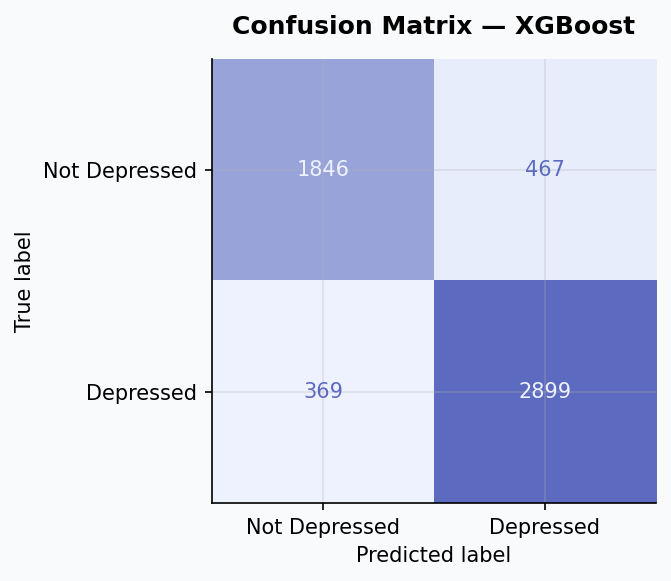

In [12]:
# ===== ADDED FOR NOTEBOOK SUPPORT =====
import matplotlib.pyplot as plt
from IPython.display import Image

cm_path = os.path.join(PROJECT_ROOT, 'plots', 'confusion_matrix.png')

if os.path.exists(cm_path):
    display(Image(cm_path, width=420))
else:
    print('Plot not found — run §2 first.')
# ===== END NOTEBOOK SUPPORT =====

---
## §5 — Cross-Validation Results


── Model Comparison — CV Accuracy ──


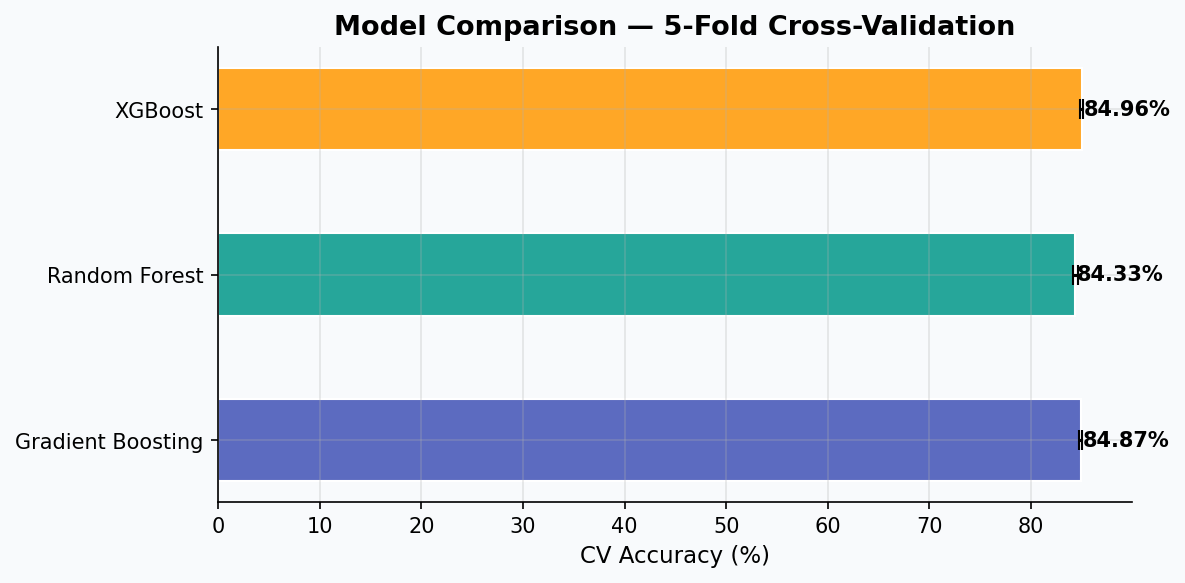


── CV Score Distribution per Model ──


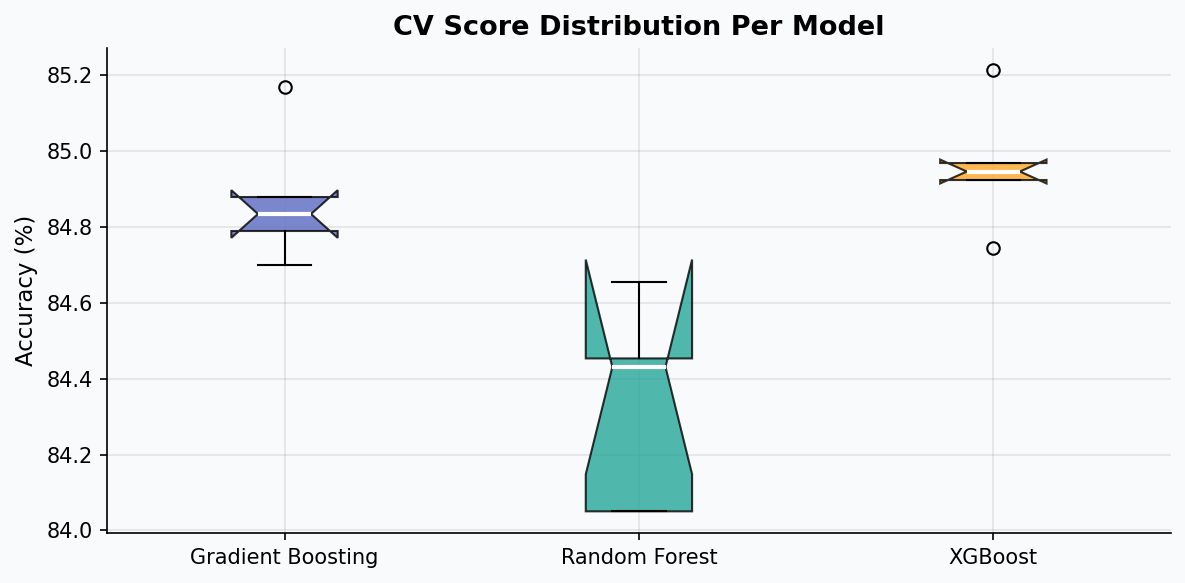


── Learning Curve ──


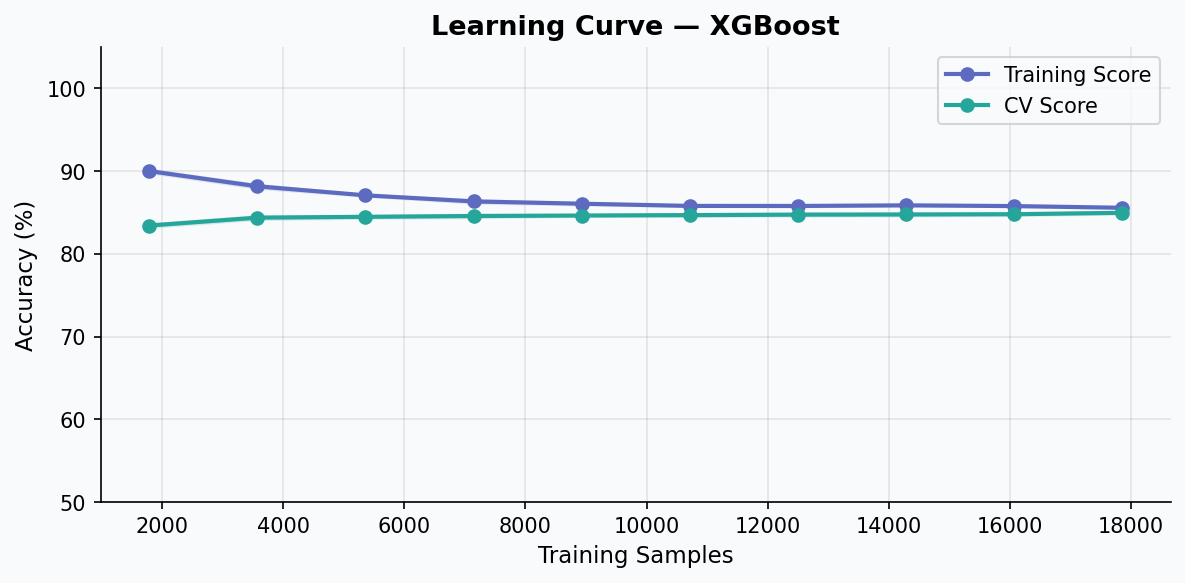

In [13]:
# ===== ADDED FOR NOTEBOOK SUPPORT =====
from IPython.display import Image

for fname, caption in [
    ('cv_comparison.png',   'Model Comparison — CV Accuracy'),
    ('cv_distribution.png', 'CV Score Distribution per Model'),
    ('learning_curve.png',  'Learning Curve'),
]:
    path = os.path.join(PROJECT_ROOT, 'plots', fname)
    if os.path.exists(path):
        print(f'\n── {caption} ──')
        display(Image(path, width=680))
    else:
        print(f'Missing: {fname}  — run §2 first.')
# ===== END NOTEBOOK SUPPORT =====

---
## §6 — Feature Importance Plots


── Feature Importance — 3 Methods ──


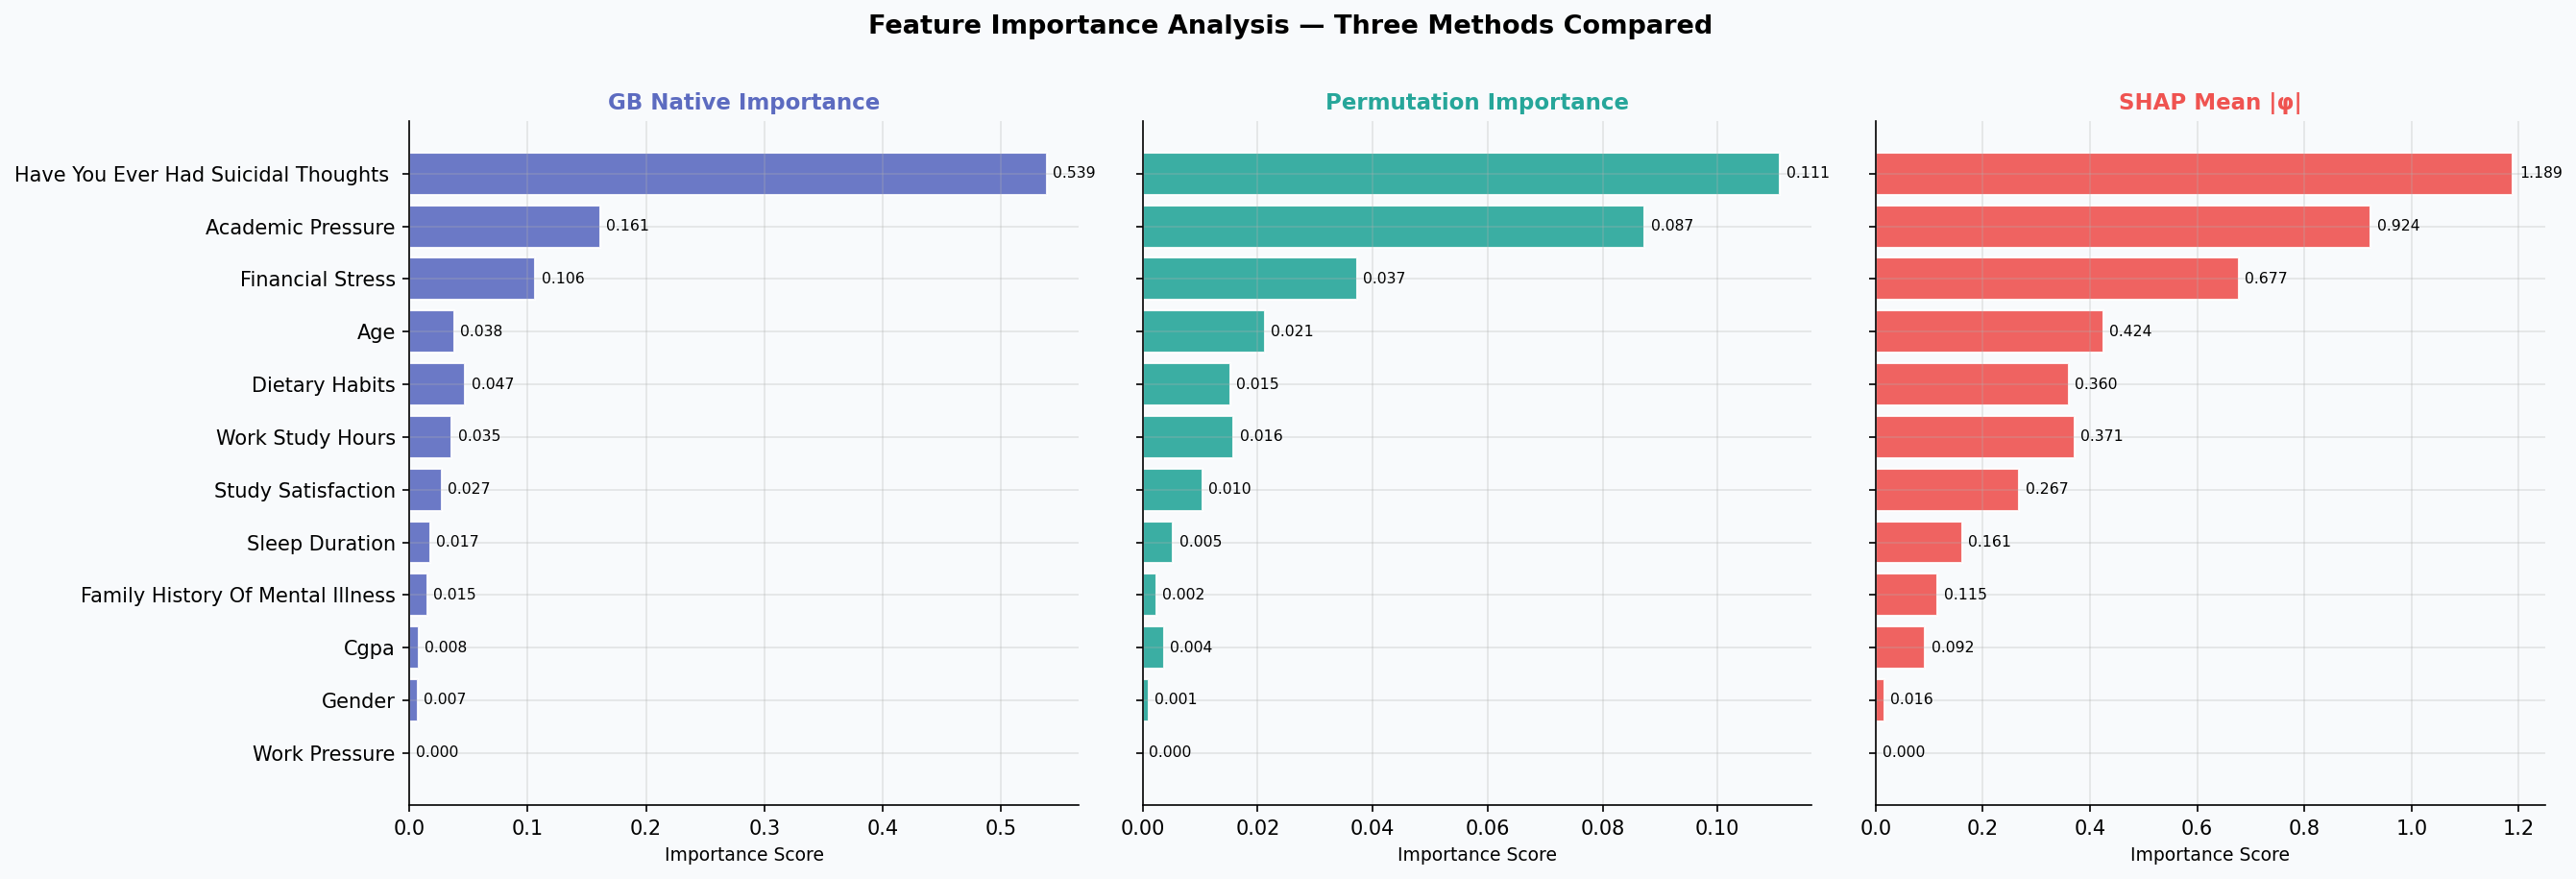


── Feature Selection: MI vs Correlation ──


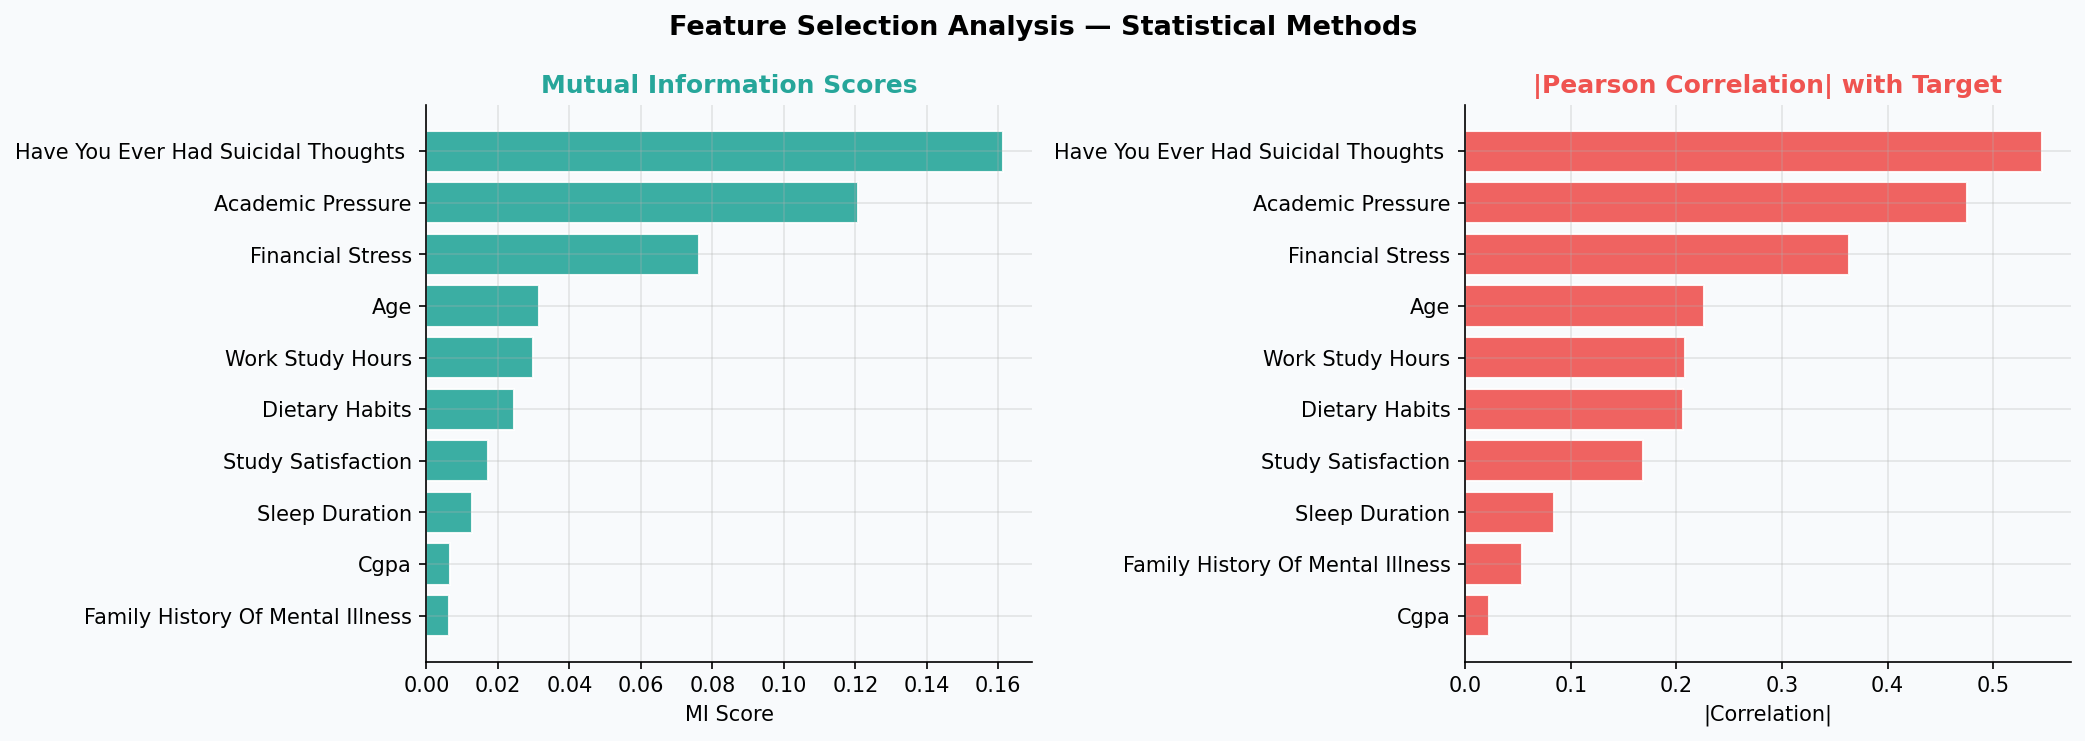


── Top-10 Features (Composite Rank) ──


,GB Native,Permutation,SHAP,Composite
Feature,,,,
have_you_ever_had_suicidal_thoughts_,0.5389,0.1108,1.1894,1.0000
academic_pressure,0.1611,0.0873,0.9236,0.6209
financial_stress,0.1062,0.0373,0.6773,0.3676
age,0.0377,0.0213,0.4242,0.2061
dietary_habits,0.0468,0.0152,0.3599,0.1755
work_study_hours,0.0355,0.0158,0.3708,0.1735
study_satisfaction,0.0272,0.0104,0.2673,0.1229
sleep_duration,0.0173,0.0053,0.1606,0.0715
family_history_of_mental_illness,0.0150,0.0024,0.1154,0.0487


In [14]:
# ===== ADDED FOR NOTEBOOK SUPPORT =====
from IPython.display import Image

for fname, caption in [
    ('feature_importance.png',         'Feature Importance — 3 Methods'),
    ('feature_selection_analysis.png', 'Feature Selection: MI vs Correlation'),
]:
    path = os.path.join(PROJECT_ROOT, 'plots', fname)
    if os.path.exists(path):
        print(f'\n── {caption} ──')
        display(Image(path, width=900))
    else:
        print(f'Missing: {fname}  — run §2 first.')

# Also show top-10 feature importance as a quick inline table
print('\n── Top-10 Features (Composite Rank) ──')
display(
    imp_df[['feature', 'native_imp', 'perm_imp', 'shap_imp', 'composite']]
    .head(10)
    .rename(columns={
        'feature':    'Feature',
        'native_imp': 'GB Native',
        'perm_imp':   'Permutation',
        'shap_imp':   'SHAP',
        'composite':  'Composite',
    })
    .set_index('Feature')
    .style.background_gradient(cmap='Blues', subset=['Composite'])
    .format('{:.4f}')
)
# ===== END NOTEBOOK SUPPORT =====

---
## §7 — Launch Streamlit App

### 👩‍🏫 Instructions for the teacher / demonstrator

1. **Make sure training is complete** (§2 ran successfully and `models/depression_model.pkl` exists).
2. **Run the cell below** — it starts the Streamlit server in the background.
3. Open your browser at **`http://localhost:8501`** (or the URL printed in the output).
4. The app will be fully interactive — fill in the sidebar, click **Predict Depression Risk**.

> ℹ️ The cell uses `!` (shell command). If you are on **JupyterLab**, the server runs as a background process and the cell returns immediately.  
> On **Google Colab**, add `&` at the end and use `npx localtunnel` to expose the port.

---

In [20]:
# ===== ADDED FOR NOTEBOOK SUPPORT =====
# Verify the model exists before launching
import os

model_pkl = os.path.join(PROJECT_ROOT, 'models', 'depression_model.pkl')
app_file  = os.path.join(PROJECT_ROOT, 'app', 'app.py')

if not os.path.exists(model_pkl):
    print('⚠️  Model not found. Please run §2 (Training Pipeline) first.')
elif not os.path.exists(app_file):
    print(f'⚠️  app.py not found at: {app_file}')
else:
    print(f'✅ Model   : {model_pkl}')
    print(f'✅ App     : {app_file}')
    print('\nLaunching Streamlit — open  http://localhost:8501  in your browser.\n')
# ===== END NOTEBOOK SUPPORT =====

✅ Model   : D:\Python_project\StudentMentalHealth2\models\depression_model.pkl
✅ App     : D:\Python_project\StudentMentalHealth2\app\app.py

Launching Streamlit — open  http://localhost:8501  in your browser.



In [17]:
# ===== ADDED FOR NOTEBOOK SUPPORT =====
# Run Streamlit.  The path is resolved dynamically so it works
# regardless of where the notebook was opened.
import subprocess, sys

app_file = os.path.join(PROJECT_ROOT, 'app', 'app.py')

# Launch as a background subprocess so the notebook stays responsive
proc = subprocess.Popen(
    [sys.executable, '-m', 'streamlit', 'run', app_file,
     '--server.headless', 'true'],
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT
)
print(f'Streamlit PID: {proc.pid}')
print('App running at: http://localhost:8501')
print('To stop: proc.terminate()  or restart the kernel.')
# ===== END NOTEBOOK SUPPORT =====

Streamlit PID: 804
App running at: http://localhost:8501
To stop: proc.terminate()  or restart the kernel.


---
## §8 — (Optional) Quick Single-Sample Prediction via Code

Demonstrates the prediction API directly from the notebook — useful for unit testing or demo narration.

In [19]:
# ===== ADDED FOR NOTEBOOK SUPPORT =====
# Import predict module — all logic lives in src/predict.py
import predict as pred_module

# Override model path to the correct location
pred_module.MODEL_PATH = os.path.join(PROJECT_ROOT, 'models', 'depression_model.pkl')
pred_module._BUNDLE    = None   # clear cache so new path is used

# Sample student profile (high-risk)
sample_high_risk = {
    'age':           22,
    'gender':        'Male',
    'cgpa':          5.5,
    'academic':      5,
    'work_pressure': 4,
    'study_sat':     1,
    'job_sat':       2,
    'work_study':    12,
    'financial':     5,
    'sleep':         'less than 5 hours',
    'diet':          'unhealthy',
    'suicid':        'Yes',
    'family':        'Yes',
}

# Sample student profile (low-risk)
sample_low_risk = {
    'age':           20,
    'gender':        'Female',
    'cgpa':          8.5,
    'academic':      2,
    'work_pressure': 1,
    'study_sat':     4,
    'job_sat':       4,
    'work_study':    6,
    'financial':     1,
    'sleep':         '7-8 hours',
    'diet':          'healthy',
    'suicid':        'No',
    'family':        'No',
}

for label, profile in [('HIGH-RISK STUDENT', sample_high_risk),
                        ('LOW-RISK STUDENT',  sample_low_risk)]:
    result = pred_module.predict(profile)
    print(f'── {label} ──')
    print(f"  Prediction  : {result['label']}")
    print(f"  Confidence  : {result['confidence']}%")
    print(f"  P(Depressed): {result['prob_dep']}%")
    print()
# ===== END NOTEBOOK SUPPORT =====

── HIGH-RISK STUDENT ──
  Prediction  : Depressed
  Confidence  : 99.69999694824219%
  P(Depressed): 99.69999694824219%

── LOW-RISK STUDENT ──
  Prediction  : Not Depressed
  Confidence  : 95.9000015258789%
  P(Depressed): 4.099999904632568%

